Chapter 30
# 多项式回归
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

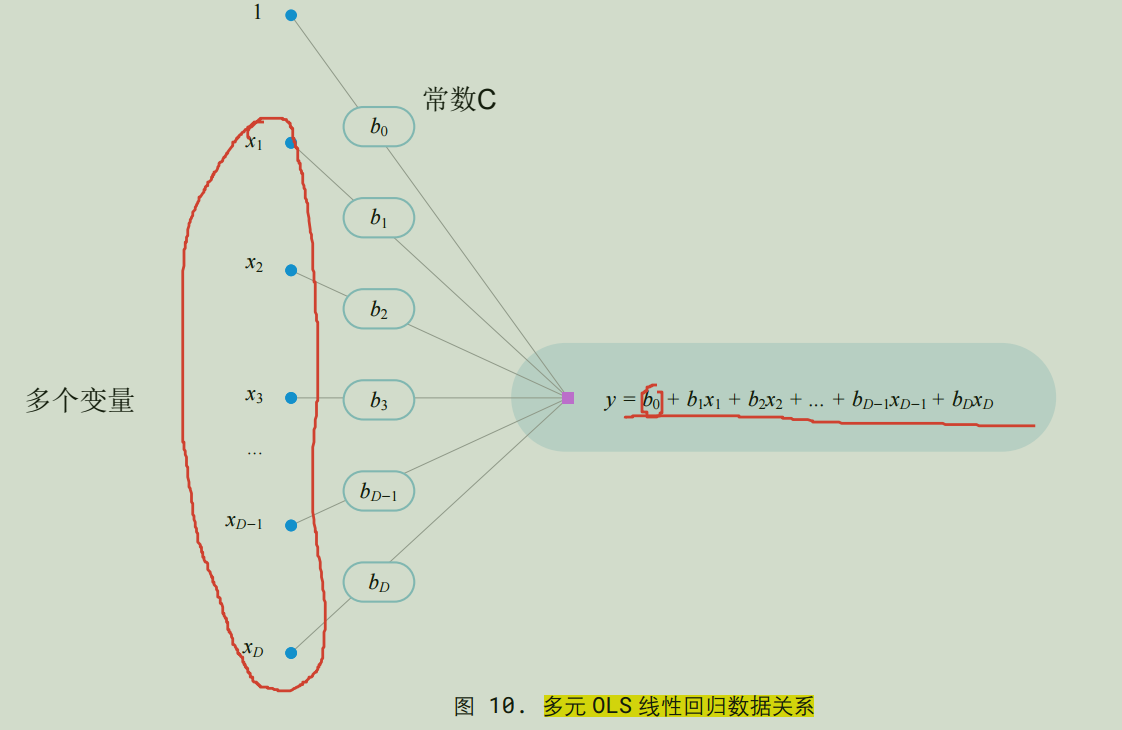

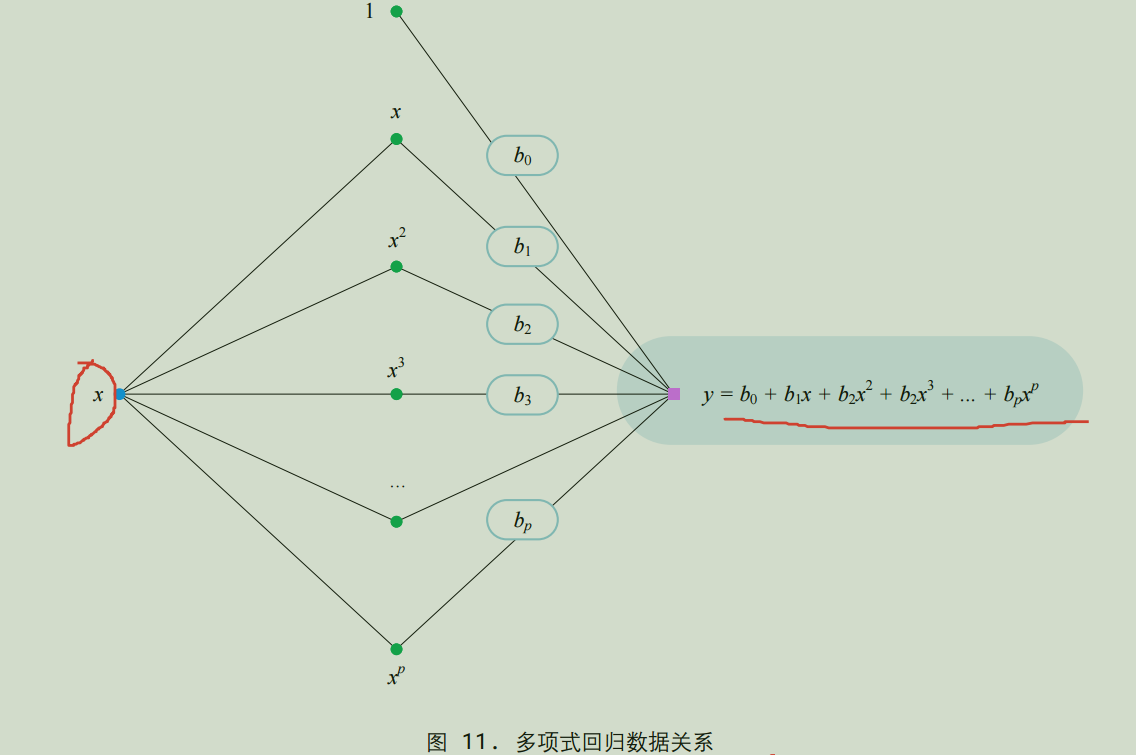

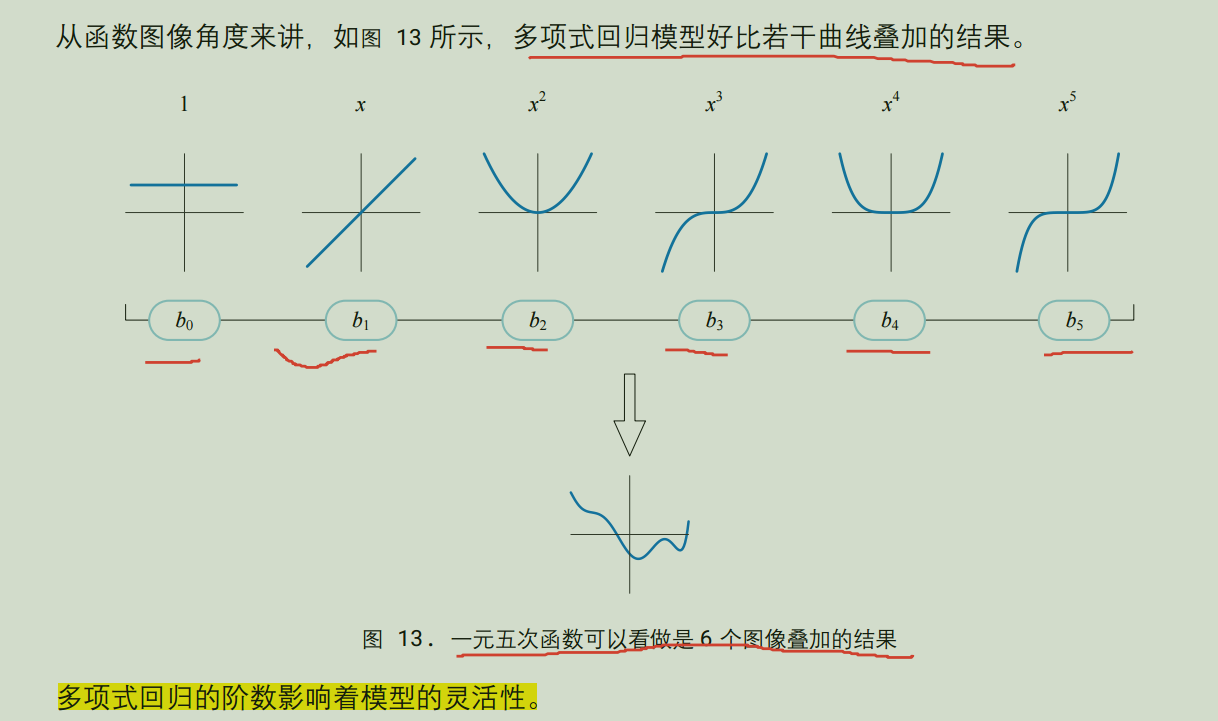

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures # 多项式
from sklearn.linear_model import LinearRegression  # 线性回归

# 生成随机数据

如图 14 所示，较低的阶数 (比如图 14 (a)、(b)) 可能无法很好地捕捉数据中的复杂关系；然
而，较高的阶数 (比如图 14 (e)、(f)) 可能会导致过度拟合。阶数越高，模型越能够适应训练数
据，但也越容易在测试数据或实际应用中表现不佳。


过拟合 (overfitting) 是指模型在训练数据上表现得很好，但在新数据上表现较差的现象。当
多项式回归的阶数过高时，模型可能会过度适应训练数据中的噪声和细节，从而失去了泛化能力
(generalization capability, generalization)。


这意味着模型对于新的、未见过的数据可能无法进行准确的预测，因为它在训练数据上“记住了”许
多细微的变化，而这些变化可能在真实数据中并不存在。


In [3]:
# 生成随机数据
np.random.seed(0) # 随机种子
num = 30 # 样本数据
X = np.random.uniform(0,4,num) # 生成数据
y = np.sin(0.4*np.pi * X) + 0.4 * np.random.randn(num) # sin(0.4πx)
data = np.column_stack([X,y]) # 将数据组合起来

从 sklearn.preprocessing 导入 PolynomialFeatures。在机器学习中，有时候原始特
征并不足够表达数据的复杂关系，这时可以引入多项式特征。
多项式特征是原始特征的幂次组合，通过引入这些特征，可以更好地拟合数据的非线性关系。


PolynomialFeatures 类的作用就是将原始特征转换为高次的多项式特征。它可以通过设置特定的
阶数来生成不同阶数的多项式特征。

In [4]:
# 生成一系列点；转为列向量
x_array = np.linspace(0,4,101).reshape(-1,1)
degree_array = [1,2,3,4,7,8] #定义列表，列表中整数为指定的多项式回归阶数 (次数)。


# 绘制图像



```
from sklearn.preprocessing import PolynomialFeatures

X = [[1], [2], [3]]  # 原始数据
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# X_poly 变成了：
# [[1, 1, 1],   # 样本1：原来的 x=1 → [1, 1, 1]  = [1, x, x²]
#  [1, 2, 4],   # 样本2：原来的 x=2 → [1, 2, 4]  = [1, x, x²]
#  [1, 3, 9]]   # 样本3：原来的 x=3 → [1, 3, 9]  = [1, x, x²]
```





```
问题：线性回归只能学 y = w·x，但 w 不能同时等于 1、2、3

多项式转换后：
                  x=1  →  变成 [1, 1, 1]  (三个数字)
                  x=2  →  变成 [1, 2, 4]  (三个数字)
                  x=3  →  变成 [1, 3, 9]  (三个数字)

线性回归现在学：y = w0·1 + w1·x + w2·x²
找到：w0=0, w1=0, w2=1
所以：y = 0 + 0·x + 1·x² = x²  ✅ 完美！
```



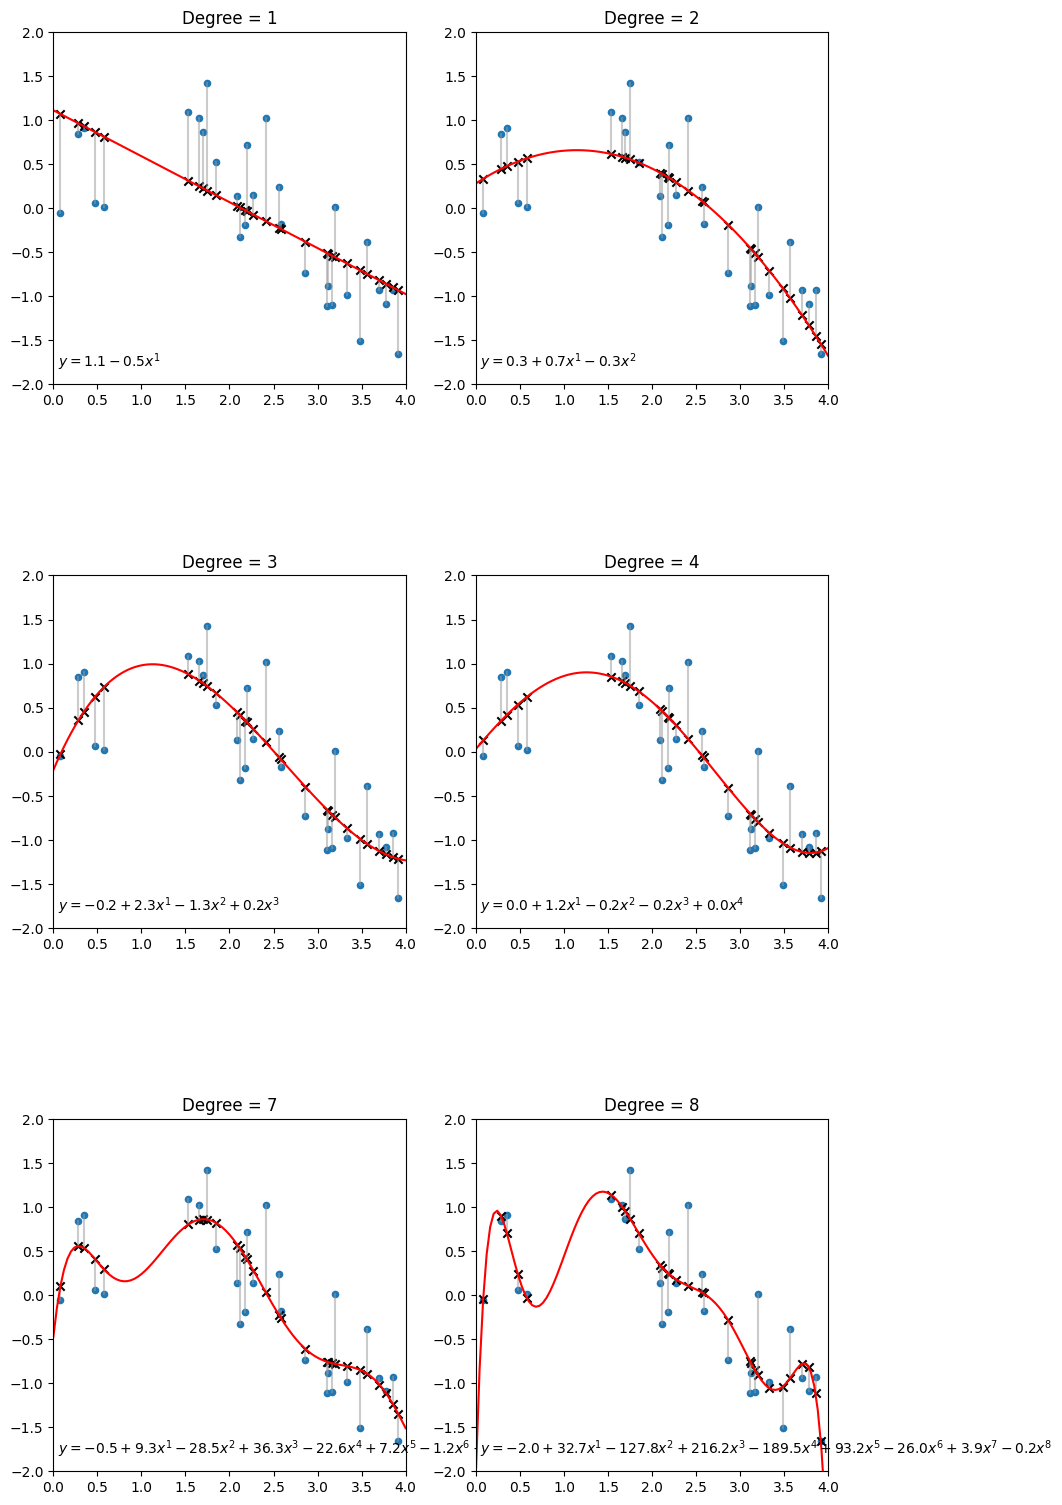

In [12]:
fig, axes = plt.subplots(3,2,figsize=(10,20))
axes = axes.flatten() # 展为一维数组

 # 类似字典； 键：值
for ax, degree_idx in zip(axes,degree_array):

    # 用 PolynomialFeatures 原始特征转换为高次的多项式特征。参数 degree 设置多项式的阶
    #  数。这个阶数决定了生成的多项式回归的最高阶数。

    poly = PolynomialFeatures(degree = degree_idx)
   # print(f"ploy: {poly}")
    # 对数据进行转换；参数为列向量；二维数组
    X_poly = poly.fit_transform(X.reshape(-1, 1))
   # print(f"X_poly: {X_poly}")

    # 训练线性回归模型
    poly_reg = LinearRegression()
    poly_reg.fit(X_poly, y) # 对数据进行拟合

    # 得出预测曲线后的数据；与y值可能不同
    y_poly_pred = poly_reg.predict(X_poly) # 预测转换后的数据
    data_ = np.column_stack([X,y_poly_pred]) # 预测数据

    # 预测坐标点的值
    y_array_pred = poly_reg.predict(
                       poly.fit_transform(x_array))

    # 绘制散点图
    ax.scatter(X, y, s=20) # 原始数据

    # 预测数据
    ax.scatter(X, y_poly_pred, marker = 'x', color='k')

    # 连接原始数据与预测数据的点
    ax.plot(([i for (i,j) in data_], [i for (i,j) in data]),
            ([j for (i,j) in data_], [j for (i,j) in data]),
             c=[0.6,0.6,0.6], alpha = 0.5)
    # 绘制多项式曲线
    ax.plot(x_array, y_array_pred, color='r')
    ax.set_title('Degree = %d' % degree_idx) # 标题

    # 提取参数
    coef = poly_reg.coef_
   # print(f"coef: {coef}")
    intercept = poly_reg.intercept_
  #  print(f"intercept: {intercept}")
    # 回归解析式
    equation = '$y = {:.1f}'.format(intercept)

    # 提取各个系数
    for j in range(1, len(coef)):
        equation += ' + {:.1f}x^{}'.format(coef[j], j)
    equation += '$'
    equation = equation.replace("+ -", "-")
    # 用 text() 在子图上打印多项式回归解析式。
    ax.text(0.05, -1.8, equation)
    ax.set_aspect('equal', adjustable='box') # 比列一致
    ax.set_xlim(0,4) # 范围
    ax.grid(False) # 不显示网格
    ax.set_ylim(-2,2)

In [6]:
len(degree_array)

6

# 打印数据

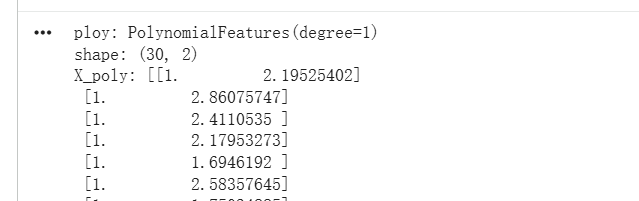

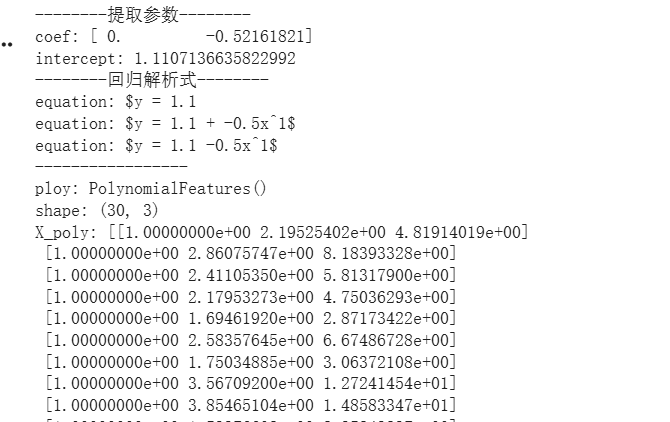

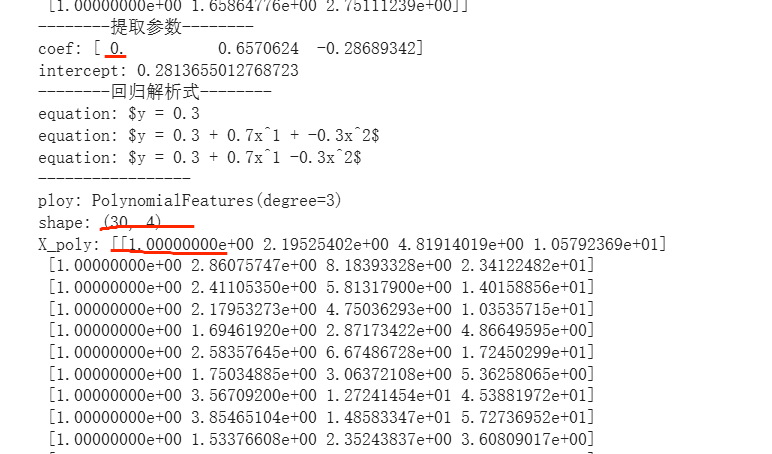

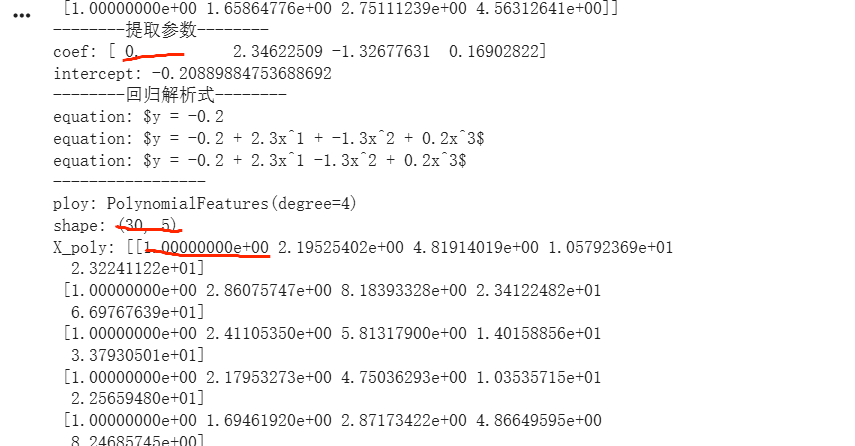

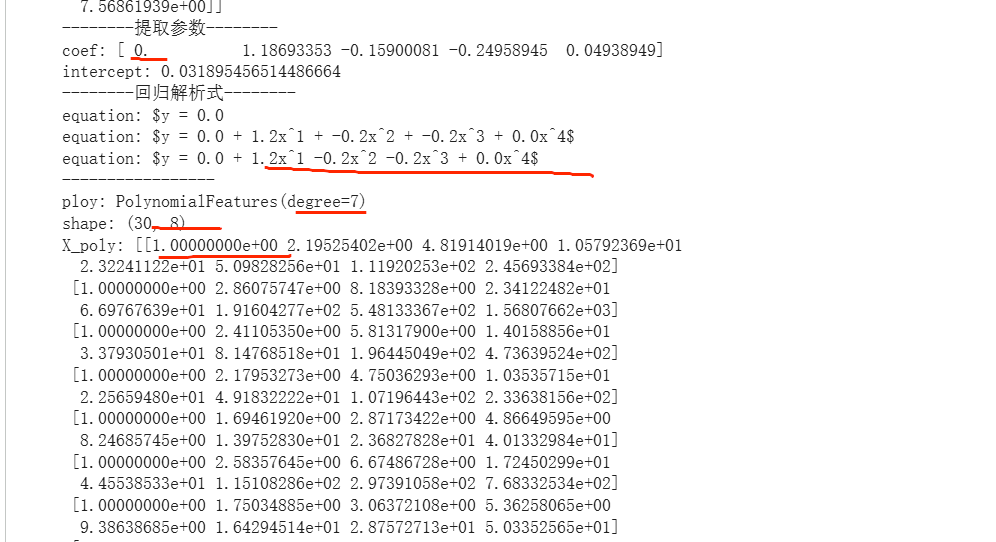

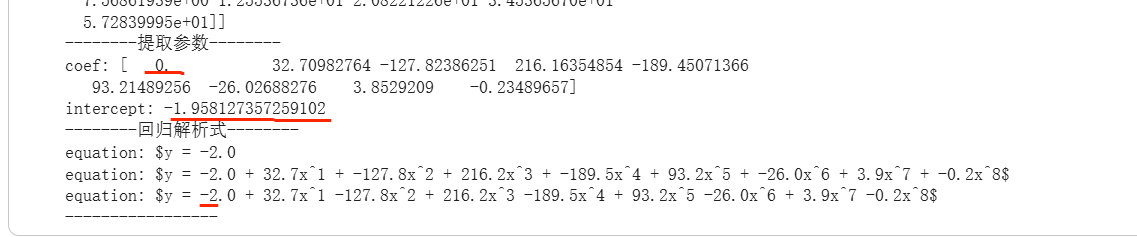

In [11]:
for i in degree_array:
    poly = PolynomialFeatures(degree = i)
    print(f"ploy: {poly}")
    # 对数据进行转换；参数为列向量；二维数组
    X_poly = poly.fit_transform(X.reshape(-1, 1))
    print(f"shape: {X_poly.shape}")
#
    print(f"X_poly: {X_poly}")

    # 训练线性回归模型
    poly_reg = LinearRegression()
    poly_reg.fit(X_poly, y) # 对数据进行拟合

    # 得出预测曲线后的数据；与y值可能不同
    y_poly_pred = poly_reg.predict(X_poly) # 预测转换后的数据
    data_ = np.column_stack([X,y_poly_pred]) # 预测数据

    # 绘制多项式曲线
    ax.plot(x_array, y_array_pred, color='r')
    ax.set_title('Degree = %d' % degree_idx) # 标题

    # 提取参数
    print("--------提取参数--------")
    coef = poly_reg.coef_
    print(f"coef: {coef}")
    intercept = poly_reg.intercept_
    print(f"intercept: {intercept}")
    # 回归解析式
    print("--------回归解析式--------")
    equation = '$y = {:.1f}'.format(intercept)
    print(f"equation: {equation}")
    # 提取各个系数
    for j in range(1, len(coef)):
        equation += ' + {:.1f}x^{}'.format(coef[j], j)
    equation += '$'
    print(f"equation: {equation}")
    equation = equation.replace("+ -", "-")
    print(f"equation: {equation}")
    print("-----------------")

ploy: PolynomialFeatures(degree=1)
shape: (30, 2)
X_poly: [[1.         2.19525402]
 [1.         2.86075747]
 [1.         2.4110535 ]
 [1.         2.17953273]
 [1.         1.6946192 ]
 [1.         2.58357645]
 [1.         1.75034885]
 [1.         3.567092  ]
 [1.         3.85465104]
 [1.         1.53376608]
 [1.         3.16690015]
 [1.         2.11557968]
 [1.         2.27217824]
 [1.         3.70238655]
 [1.         0.28414423]
 [1.         0.3485172 ]
 [1.         0.08087359]
 [1.         3.33047938]
 [1.         3.112627  ]
 [1.         3.48004859]
 [1.         3.91447337]
 [1.         3.19663426]
 [1.         1.84591745]
 [1.         3.12211671]
 [1.         0.4730977 ]
 [1.         2.55968409]
 [1.         0.57341315]
 [1.         3.77867567]
 [1.         2.08739329]
 [1.         1.65864776]]
--------提取参数--------
coef: [ 0.         -0.52161821]
intercept: 1.1107136635822992
--------回归解析式--------
equation: $y = 1.1
equation: $y = 1.1 + -0.5x^1$
equation: $y = 1.1 -0.5x^1$
---------